<div style="text-align: center;">
    <h1 style="margin-bottom: 0px; padding-bottom: 0px;">
        "Actividad primaria y educación superior en la provincia de Melipilla: análisis bivariado y comparación censal 2017-2024"
    </h1>
    <p style="margin-top: 5px; font-size: 16px; text-align: center">
        Renato Durán Morales
    </p>
</div>

## 1. Introducción


Los territorios rurales presentan diferencias en su estructura productiva,    conectividad, acceso a servicios y características sociodemográficas. Por esta
razón, la ruralidad no puede explicarse únicamente mediante la proporción de
población rural, sino que también deben considerarse la actividad económica, el
capital humano y la relación con los centros urbanos (Berdegué et al., 2010). 
    
En Chile, los mercados laborales rurales han experimentado una progresiva
diversificación, aunque las actividades agrícolas y extrativas continúan teniendo una presencia importnate en determinados territorios (Pérez Silva, 2023). Estas tranasformaciones también han modificado la relación entre residencia y trabajo, debido a que parte de la población ocupada en actividades agrícolas vive en centros urbanos, mientras que algunos habitantes rurales trabajan en actividades no agrícolas (Canales et al., 2018). 

El nivel educativo constituye otra dimensión relevante para comprender estas diferencias territoriales. Las zonas rurales suelen enfrentar brechas en ele acceso a la formación técnica y profesional, junto con dificultadoes para vincular la oferta educativa con las necesidades de los sectores productivos locales (Kerrigan Richard, 2017). Sin embargo, l arelación entre actividad primaria y educación suparior no es necesariamente enversa, ya que los territorios rurales-urbanos pueden combinar actividades basadas en recursos naturales con una mayor diversificación económica y presencia de población calificada (Cazzuffi et al., 2019). 

En este contexto, la provincia de Melipilla se considera como un caso de análisis que permite observar la coexistencia de centros urbanos, localidades rurales y sectores con atividades silvoagropecuaria. De acuerdo con la Oficina de Estudios y Políticas Agrarias (ODEPA) (2019), la provincia concentra una parte relevante de la superficie frutícola de la Región Metropolitana, principalmente en las comunas de Melipilla, María Pinto y San Pedro. En función de lo anterior, el prensente informe analizará la relación espacial entre el porcentaje de población ocupada en actividades primarias y el porcentaje de población con educación profesional o de posgrado completa, comparando las zonas censales de la provincia entre 2017 y 2024. 

### 1.1. Objetivo general 

Analizar la relación espacial entre el porcentaje de población ocupada en actividades primarias y el porcentaje de población con educación profesioanl o de posgrado completa en las zonas censales de la provincia de Melipilla, mediante una comparación de los resultados de los censos 2017 y 2024. 

### 1.2. Objetivos específicos 

* Constuir indicadores porcenturales para 2017 y 2024.
* Mapear la distribución espacial de ambos indicadores.
* Elaborar mapas bivariados.
* Comparar patrones espaciales entre 2017 y 2024.
* Interpretar los resultados territoriales.
* Evaluar su utilidad para la planificación. 

---

## 2. Desarrollo

### 2.1. Procesamiento y análisis del Censo 2017

Para analizar la relación entre actividad económica primaria y la educación superior en la provincia de Melipilla, se procesaron datos censales correspondientes a los años 2017 y 2024 mediante Python. En el análisis se desarrolló a nivel de zona censal e incluyó la conexión y carga de las bases de datos, el cálculo de los indicadores, la exploración estadística y la elaboración de mapas individuales y bivariados. 

Para 2017, los daots personales, hogares, viviendas y zonas censales se obtuvieron desde una base PostgreSQL. En el caso de 2024, se utilizó un archivo geoespacial en formato Parquet que las geometrías de las zonas censales.

#### 2.1.1. Librerías utilizadas 

En primer lugar, se cargan las librerías necearias para la conexión con la base de datos, manimupalción de tablas, procesamiento geoespacial, clasificación de los indicadores y elaboración de gráficos y mapas. 

In [1]:
## Agregamos la librería que utilizaremos.
!conda install -y pyarrow
! pip install pyreadr
from sqlalchemy import create_engine
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import mapclassify 
import matplotlib.patheffects as pe
from matplotlib.lines import Line2D
import numpy as np
import pyreadr

Solving environment: ...working... done

# All requested packages already installed.





==> WARNING: A newer version of conda exists. <==
  current version: 23.7.4
  latest version: 26.5.3

Please update conda by running

    $ conda update -n base -c defaults conda

Or to minimize the number of packages updated during conda update use

     conda install conda=26.5.3




pandas y geopandas se utilizaron para manipular los datos tabulares y geoespaciales, mientras que matplotlib y <seaborn> permitieron generar los mapas y gráficos. La librería mapclassify se empleó para clasificar los indicadores mediante el método Fisher-Jenks. 

#### 2.1.2. Procesamiento de los datos del Censo 2017

##### 2.1.2.1. CONEXIÓN BASE DE DATOS

Los datos censales de 2017 se encuentran almacenados en una base PostgreSQL denominada censo 2017. 

In [2]:
## Conectamos con postgresql
DB_HOST = 'localhost'
DB_PORT = 5432
DB_NAME = 'rm_censo_2017'
DB_USER = 'postgres'
DB_PASSWORD = 'postgres' 

engine = create_engine(
    f'postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}')

##### 2.1.2.2. Carga de límites comunales 

Posteriormente, se cargó la capa de comunas de la Región Metropolitana. Esta información se utilizó para representar los limites administrativos y agregar los nombres de las comunas en los mapas. 

In [3]:
## Cargamos la comuna, con su respectivo nombre y su geometría.

sql_comunas = '''
SELECT nom_comuna, geom
FROM dpa.comunas_rm_shp;
'''

gdf_comunas    = gpd.read_postgis(sql_comunas, engine, geom_col='geom')
gdf_centroides = gdf_comunas.copy()
gdf_centroides['geometry'] = gdf_comunas.centroid

print(f'Comunas: {len(gdf_comunas)}')
display(gdf_comunas)

Comunas: 52


,nom_comuna,geom
0,LO PRADO,"MULTIPOLYGON (((339891.406 6298725.5, 339967.9..."
1,INDEPENDENCIA,"MULTIPOLYGON (((345568.713 6303028.6, 345794.7..."
2,LO ESPEJO,"MULTIPOLYGON (((344800.111 6290835.676, 343521..."
3,SAN RAMÓN,"MULTIPOLYGON (((348001.245 6290000.561, 348259..."
4,LA CISTERNA,"MULTIPOLYGON (((346490 6286649.498, 345256.375..."
5,PEDRO AGUIRRE CERDA,"MULTIPOLYGON (((344800.111 6290835.676, 342530..."
6,SAN MIGUEL,"MULTIPOLYGON (((348011.801 6290001.611, 348001..."
7,CONCHALÍ,"MULTIPOLYGON (((342803.041 6306876.533, 343470..."
8,SAN JOAQUÍN,"MULTIPOLYGON (((349191.057 6294882.314, 349437..."
9,LA GRANJA,"MULTIPOLYGON (((350573.769 6287953.638, 350492..."


#### 2.1.3. Indicadores

Para analizar la relación entre la actividad económica primaria y la educación superior se construyeron dos indicadores porcentuales a nivel de zona censal. Los cálculos fueron realizados mediante una consulta SQL que relaciona los registros de personas con las tablas de hogares, viviendas y unidades territoriales. 

Posteriormente, los resultados fueron vinculados con la geometría de las zonas censales mediante su geocódigo. 

El primer indicador corresponde al porcentaje de personas clasificadas en actividades económicas primarias. Para su construcción se utilizaron las categorías A y B de la variable p18, asociada con la rama de actividad económica. La categoría A comprende agricultura, ganadería, silvicultura y pesca, mientras que la categoría B corresponde a explotación de minas y canteras.

La fórmula aplicada fue:

$$
\text{Actividad primaria 2017 (\%)} =
\frac{\text{Personas clasificadas en las actividades A y B}}
{\text{Población total de la zona censal}}
\times 100
$$

El segundo indicador corresponde al porcentaje de personas con nivel profesional aprobado. Para su cálculo se seleccionaron los registros que presentan el valor 12 en la variable p15.

$$
\text{Población profesional 2017 (\%)} =
\frac{\text{Personas con nivel profesional aprobado}}
{\text{Población total de la zona censal}}
\times 100
$$

Los resultados fueron redondeados a dos decimales y agrupados según zona censal. Además, la consulta se restringió a las comunas pertenecientes a la provincia de Melipilla.

En ambos indicadores se utilizó como denominador el total de personas registradas en cada zona. Por consiguiente, el indicador de sector primario no expresa el porcentaje dentro de la población ocupada, sino la presencia de personas clasificadas en las ramas A y B respecto de toda la población zonal. De igual manera, el indicador profesional representa la proporción respecto de la población total y no exclusivamente de la población adulta.

In [4]:
## Definimos nuestras variables, las cuales son: Personas que trabajan en el sector primario y Personas que terminron una carrera profesional
## (incluyendo quienes tienen magister o doctorado).

## Calcular el sector primario en porcentaje: (sumando A y B, dividido por total de personas de la zona)*100
## # Calcular los profesionales en porcentaje (cantidad de personas con nivel profesional aprobado, dividido por el total de personas)*100

sql_indicadores = '''
WITH agg AS 
(
SELECT c.nom_comuna, 
z.geocodigo::DOUBLE PRECISION AS geocodigo, 
ROUND (((COUNT(*) FILTER (WHERE UPPER(p.p18) IN ('A', 'B')))*100.0/COUNT(*)),2) AS sector_primario,
ROUND (((COUNT(*) FILTER (WHERE p.p15 = 12))*100.0/COUNT(*)),2) AS porcentaje_profesionales
FROM public.personas AS p
JOIN public.hogares AS h
ON p.hogar_ref_id = h.hogar_ref_id
JOIN public.viviendas AS v
ON h.vivienda_ref_id = v.vivienda_ref_id
JOIN public.zonas AS z
ON v.zonaloc_ref_id = z.zonaloc_ref_id
JOIN public.comunas AS c
ON z.codigo_comuna = c.codigo_comuna
JOIN public.provincias AS pr 
ON pr.provincia_ref_id = c.provincia_ref_id
WHERE pr.nom_provincia = 'MELIPILLA'
GROUP BY c.nom_comuna, z.geocodigo
)
SELECT a.*, shp.geom
FROM agg AS a
JOIN dpa.zonas_censales_rm AS shp
ON shp.geocodigo = a.geocodigo;
'''

In [5]:
## Creamos la variable gdf que contiene nuestros indicadores calculados en porcentaje y la geometría, con el geocodigo de la
## zona censal y a que comuna pertenece.

gdf = gpd.read_postgis(sql_indicadores, engine, geom_col='geom')

In [6]:
gdf

,nom_comuna,geocodigo,sector_primario,porcentaje_profesionales,geom
0,ALHUÉ,1.350201e+10,18.37,9.35,"MULTIPOLYGON (((306250.709 6232826.305, 306344..."
1,ALHUÉ,1.350201e+10,14.58,0.00,"MULTIPOLYGON (((304044.672 6232382.536, 304070..."
2,ALHUÉ,1.350202e+10,34.98,3.67,"MULTIPOLYGON (((295472.326 6234041.035, 295780..."
3,ALHUÉ,1.350202e+10,45.07,14.08,"MULTIPOLYGON (((291374.242 6233598.206, 291459..."
4,ALHUÉ,1.350203e+10,16.65,5.22,"MULTIPOLYGON (((311500.554 6233729.707, 311534..."
...,...,...,...,...,...
219,SAN PEDRO,1.350506e+10,19.27,6.42,"MULTIPOLYGON (((270726.55 6239669.063, 270758...."
220,SAN PEDRO,1.350506e+10,17.96,5.83,"MULTIPOLYGON (((263857.95 6238016.555, 264500...."
221,SAN PEDRO,1.350506e+10,19.80,2.48,"MULTIPOLYGON (((266072.646 6242106.632, 266163..."
222,SAN PEDRO,1.350506e+10,20.69,1.38,"MULTIPOLYGON (((263628.433 6239389.385, 263669..."


#### 2.1.4. Análisis exploratorio de los indicadores

Una vez construidos los indicadores, se calcularon estadísticas descriptivas para examinar su distribución. La tabla presenta el número de zonas censales, la media, la desviación estándar, los valores mínimos y máximos y los cuartiles de cada variable. Esta revisión permitió reconocer la amplitud de los porcentajes y detectar posibles diferencias entre las zonas antes de realizar su representación cartográfica.

Este nos permite identificar la amplitud de los valores, reconocer posibles diferencias entre las zonas censales y detectar la existencia de valores extremos antes de realizar la representación cartográfica. Además, entrega una referencia inicial para interpretar los mapas individuales y bivariados.

In [6]:
## Generamos una tabla resumen de las variables.

gdf[['sector_primario','porcentaje_profesionales']].describe().round(2)

,sector_primario,porcentaje_profesionales
count,224.00,224.00
mean,13.69,9.19
std,9.49,7.50
min,0.00,0.00
25%,6.49,4.40
50%,12.50,7.09
75%,18.39,11.34
max,75.00,41.10


#### 2.1.5. Mapas individuales

Para representar territorialmente los indicadores se prepararon las capas correspondientes a las zonas censales y a los límites comunales de la provincia de Melipilla. En primer lugar, se seleccionaron las comunas de Alhué, Curacaví, María Pinto, Melipilla y San Pedro. Posteriormente, se calcularon los centroides de las comunas para incorporar sus nombres como etiquetas dentro de los mapas.

Además, se definió una función de representación cartográfica que permite aplicar una escala de colores a cada indicador, superponer los límites comunales, añadir las etiquetas territoriales y configurar los elementos gráficos de manera homogénea. El uso de una función común facilita la comparación visual entre ambos indicadores, ya que mantiene el mismo diseño cartográfico y modifica únicamente la variable y la paleta de colores utilizada.

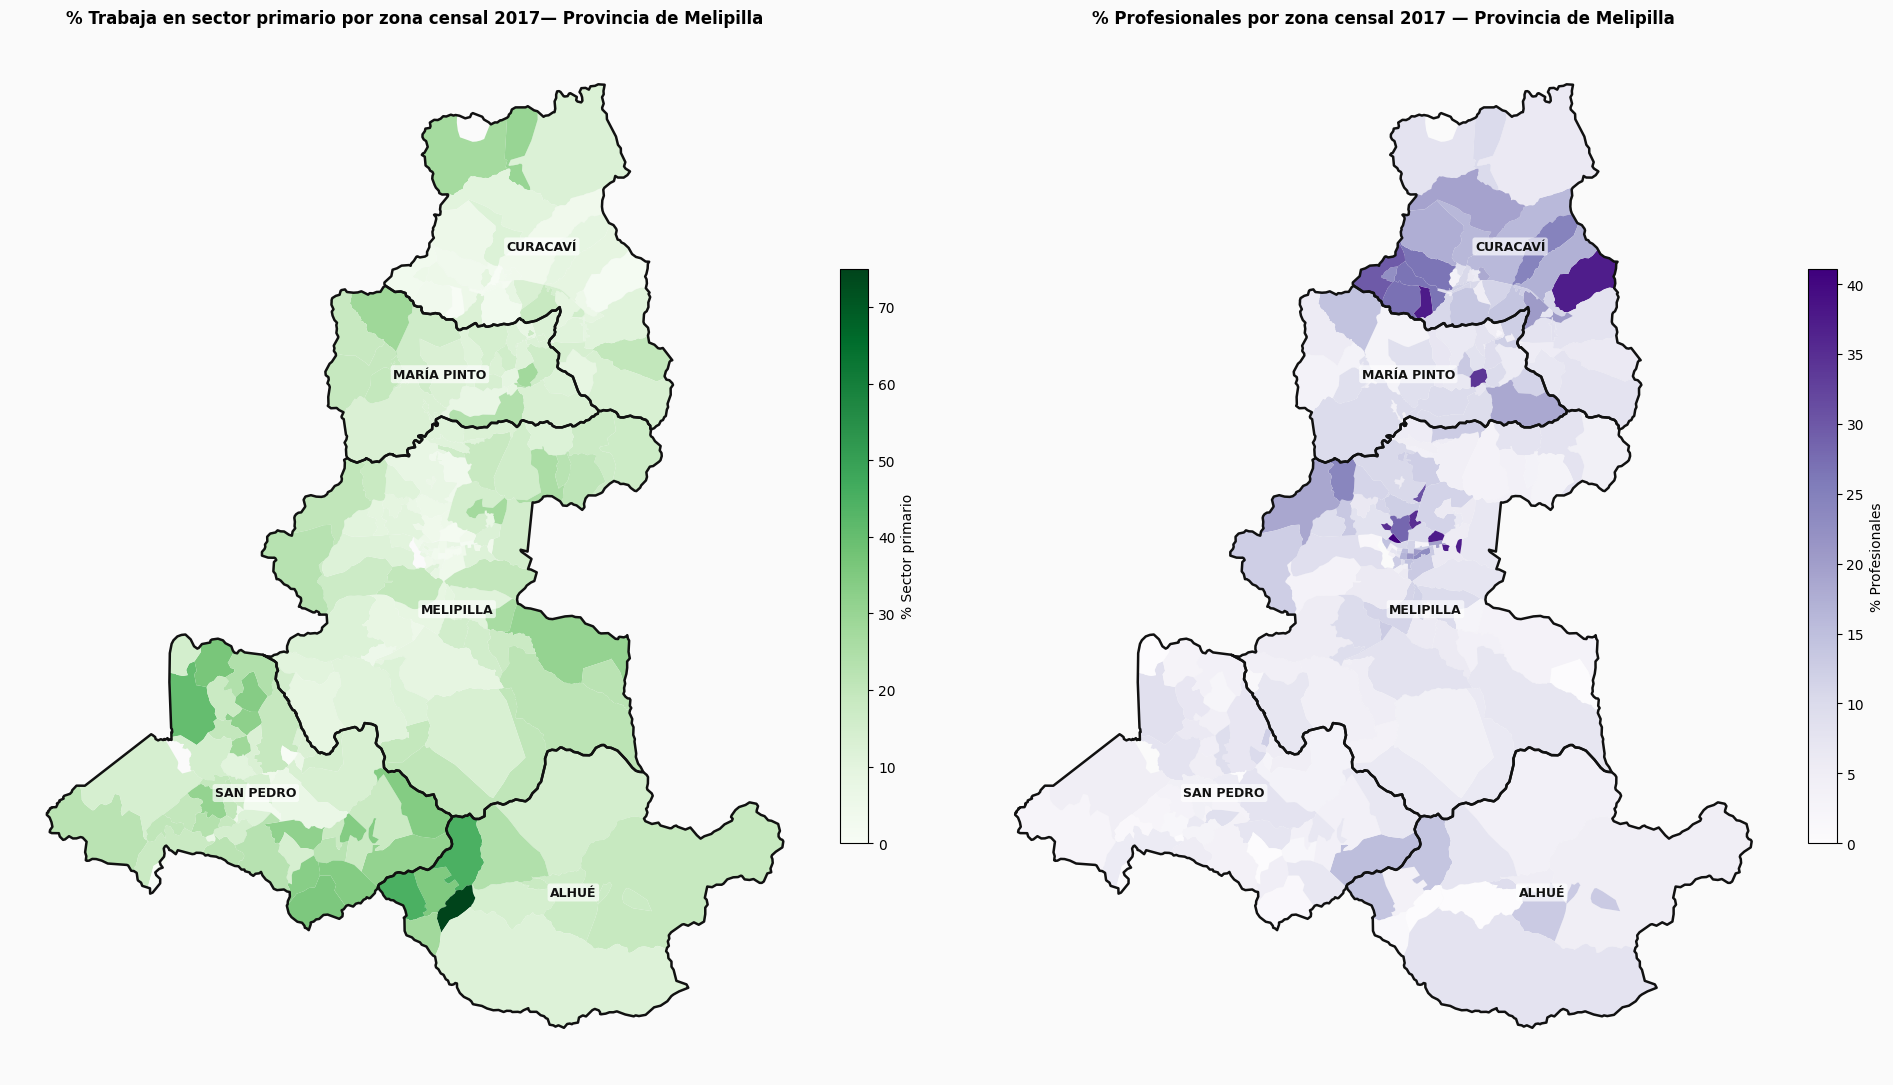

In [7]:
## Generamos mapa para cada variable y poder observar como se disponen los porcentajes en el espacio.

def plot_univariado(ax, gdf_z, gdf_c, gdf_ct, col, cmap, titulo, cbar_label):
    gdf_z.plot(
        column=col, ax=ax, cmap=cmap, linewidth=0,
        legend=True,
        legend_kwds={'label': cbar_label, 'shrink': 0.55, 'pad': 0.02}
    )
    gdf_c.plot(ax=ax, facecolor='none', edgecolor='#111', linewidth=1.8)
    for _, row in gdf_ct.iterrows():
        ax.annotate(
            row['nom_comuna'],
            xy=(row.geometry.x, row.geometry.y),
            ha='center', va='center',
            fontsize=9, fontweight='bold', color='#111',
            bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.65, ec='none')
        )
    ax.set_title(titulo, fontsize=12, fontweight='bold', pad=10)
    ax.axis('off')

comunas_melipilla = ['MELIPILLA', 'MARÍA PINTO', 'CURACAVÍ', 'ALHUÉ', 'SAN PEDRO']

gdf_comunas_mel = gdf_comunas[gdf_comunas['nom_comuna'].str.upper().isin(comunas_melipilla)]
gdf_centroides_mel = gdf_centroides[gdf_centroides['nom_comuna'].str.upper().isin(comunas_melipilla)]

gdf_mel = gdf[gdf['nom_comuna'].str.upper().isin(comunas_melipilla)]

fig, axes = plt.subplots(1, 2, figsize=(20, 11))
fig.patch.set_facecolor('#fafafa')

plot_univariado(
    axes[0], gdf_mel, gdf_comunas_mel, gdf_centroides_mel,
    'sector_primario', 'Greens',
    '% Trabaja en sector primario por zona censal 2017— Provincia de Melipilla',
    '% Sector primario'
)

plot_univariado(
    axes[1], gdf_mel, gdf_comunas_mel, gdf_centroides_mel,
    'porcentaje_profesionales', 'Purples',
    '% Profesionales por zona censal 2017 — Provincia de Melipilla',
    '% Profesionales'
)

plt.tight_layout(pad=2)
plt.show()

El mapa de actividad primaria muestra una mayor concentración en sectores rurales y periféricos de la provincia, especialmente en San Pedro y en zonas próximas al límite entre Melipilla y Alhué. En cambio, las áreas centrales de Melipilla y parte de Curacaví presentan valores más bajos. En el sector sur, los porcentajes elevados pueden relacionarse tanto con actividades agrícolas como con la explotación de minas y canteras, ya que ambas ramas forman parte del indicador.

La distribución de la población profesional presenta un patrón distinto. Las mayores proporciones se concentran principalmente en Curacaví y en algunas zonas centrales de Melipilla, mientras que San Pedro y Alhué registran valores generalmente menores. María Pinto presenta una situación intermedia, con algunas concentraciones puntuales.

En conjunto, se observa una tendencia espacial en la que las zonas con mayor presencia de actividades primarias suelen presentar una menor proporción de profesionales. 

#### 2.1.6. Clasificación de cuadrante de colores

Para representar conjuntamente ambos indicadores, sus valores fueron clasificados en tres niveles: bajo, medio y alto. La clasificación se realizó mediante el método Fisher-Jenks, el cual agrupa valores semejantes y busca maximizar las diferencias entre las categorías resultantes.

Posteriormente, las tres categorías del sector primario se combinaron con las tres categorías del porcentaje de profesionales, generando una matriz bivariada de nueve clases. En esta matriz, el primer número identifica el nivel de actividad primaria y el segundo corresponde al nivel de población profesional.

De este modo, la categoría 1-1 representa zonas con valores bajos en ambos indicadores, mientras que 3-3 identifica zonas con una presencia alta tanto de actividad primaria como de población profesional. Las categorías 3-1 y 1-3 permiten reconocer los principales contrastes territoriales: alta actividad primaria con baja presencia de profesionales, y baja actividad primaria con alta presencia de profesionales, respectivamente.

La escala combina tonalidades verdes y moradas. Los colores más verdes indican una mayor participación del sector primario, mientras que los tonos morados representan una mayor presencia de población profesional. Las tonalidades intermedias u oscuras reflejan distintas combinaciones entre ambos indicadores.

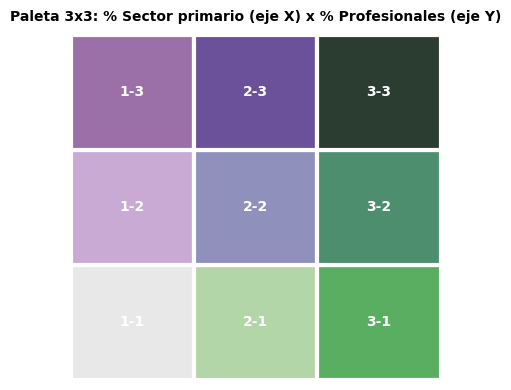

In [8]:
## Definimos cantidad de cuadrantes y sus respectivos colores en preparación pora el mapa bivariado.

BIVARIATE_COLORS = {
    '1-1': '#e8e8e8',  # bajo-bajo   → neutro claro
    '2-1': '#b2d6a7',  # medio-bajo  → verde claro
    '3-1': '#5aae61',  # alto-bajo   → verde pleno
    '1-2': '#c8aad4',  # bajo-medio  → morado claro
    '2-2': '#9090bc',  # medio-medio → pizarra azul
    '3-2': '#4d8e6e',  # alto-medio  → verde-azul oscuro
    '1-3': '#9b6fa8',  # bajo-alto   → morado pleno
    '2-3': '#6b509a',  # medio-alto  → morado profundo
    '3-3': '#2b3d30',  # alto-alto   → verde muy oscuro
}

# Visualizar la paleta como grilla
fig_pal, ax_pal = plt.subplots(figsize=(4, 4))
for key, color in BIVARIATE_COLORS.items():
    i, j = map(int, key.split('-'))
    ax_pal.add_patch(plt.Rectangle(
        ((i - 1) / 3, (j - 1) / 3), 1/3, 1/3,
        transform=ax_pal.transAxes,
        facecolor=color, edgecolor='white', linewidth=3, clip_on=False
    ))
    ax_pal.text(
        (i - 0.5) / 3, (j - 0.5) / 3, key,
        ha='center', va='center', fontsize=10, color='white',
        fontweight='bold', transform=ax_pal.transAxes
    )
ax_pal.set_xlim(0, 1)
ax_pal.set_ylim(0, 1)
ax_pal.axis('off')
ax_pal.set_title('Paleta 3x3: % Sector primario (eje X) x % Profesionales (eje Y)',
                 fontsize=10, fontweight='bold', pad=10)
plt.tight_layout()
plt.show()

In [12]:
cls_x = mapclassify.FisherJenks(gdf['sector_primario'].values,    k=3)
cls_y = mapclassify.FisherJenks(gdf['porcentaje_profesionales'].values, k=3)

gdf_bi = gdf.copy()
gdf_bi['class_x']  = cls_x.yb + 1 
gdf_bi['class_y']  = cls_y.yb + 1
gdf_bi['bi_class'] = gdf_bi['class_x'].astype(str) + '-' + gdf_bi['class_y'].astype(str)
gdf_bi['color']    = gdf_bi['bi_class'].map(BIVARIATE_COLORS)

print('Cortes Jenks — % Migrantes:')
print([round(b, 2) for b in cls_x.bins])
print('\nCortes Jenks — % Escolaridad >= 16:')
print([round(b, 2) for b in cls_y.bins])
print(f'\nDistribucion de clases bivariadas:')
print(gdf_bi['bi_class'].value_counts().sort_index())

sin_color = gdf_bi[gdf_bi['color'].isna()]
if len(sin_color) == 0:
    print('\nTodas las zonas tienen color asignado')
else:
    print(f'\nAtencion: {len(sin_color)} zonas sin color: {sin_color["bi_class"].unique()}')

Cortes Jenks — % Migrantes:
[11.15, 24.2, 75.0]

Cortes Jenks — % Escolaridad >= 16:
[8.79, 21.33, 41.1]

Distribucion de clases bivariadas:
bi_class
1-1    39
1-2    42
1-3    15
2-1    83
2-2    21
2-3     1
3-1    18
3-2     5
Name: count, dtype: int64

Todas las zonas tienen color asignado


C:\Users\renat\anaconda3\envs\geo\Lib\site-packages\IPython\core\interactiveshell.py:3526: UserWarning: Numba not installed. Using slow pure python version.
  exec(code_obj, self.user_global_ns, self.user_ns)


El cuadrante permite interpretar de manera conjunta la situación de cada zona censal. La lectura se realiza desde los valores bajos hacia los altos en ambos ejes: el eje horizontal representa el incremento de la actividad primaria y el eje vertical el aumento de la población profesional. Esta referencia será utilizada para interpretar los colores asignados posteriormente en el mapa bivariado.

#### 2.1.7. Mapa Bivariados de 2017

A partir de la clasificación anterior, se elaboró un mapa bivariado para representar simultáneamente el porcentaje de población vinculada con el sector primario y el porcentaje de población profesional en cada zona censal de la provincia de Melipilla.

Cada color corresponde a una combinación entre los niveles bajo, medio y alto de ambos indicadores. De esta manera, el mapa permite identificar zonas donde predominan las actividades primarias, zonas con una mayor presencia de profesionales y sectores donde ambos indicadores presentan niveles similares o contrastantes.

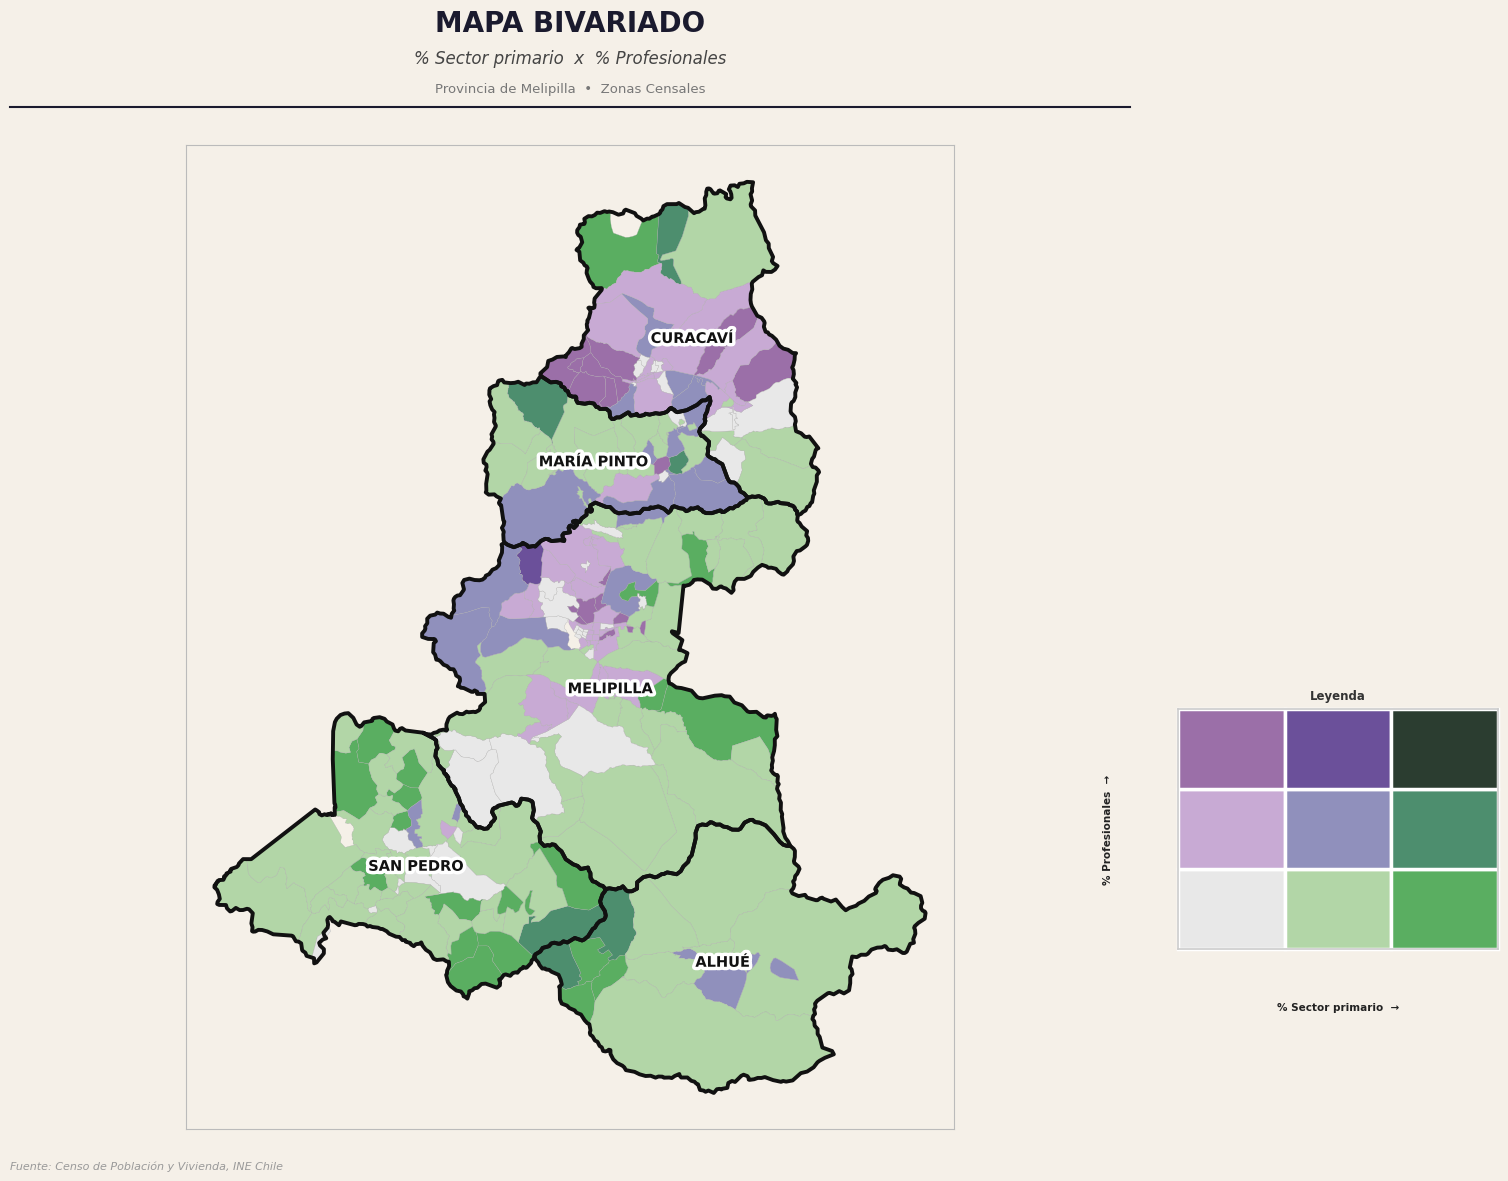

In [13]:
##Definir y filtrar las comunas de Melipilla.
comunas_mel = ['MELIPILLA', 'MARÍA PINTO', 'CURACAVÍ', 'ALHUÉ', 'SAN PEDRO']

gdf_bi_mel = gdf_bi[gdf_bi['nom_comuna'].str.upper().isin(comunas_mel)]
gdf_comunas_mel = gdf_comunas[gdf_comunas['nom_comuna'].str.upper().isin(comunas_mel)]
gdf_centroides_mel = gdf_centroides[gdf_centroides['nom_comuna'].str.upper().isin(comunas_mel)]

## Función para la leyenda bivariada.
def crear_leyenda_bivariada(ax, colores, xlab, ylab, dim=3):
    for i in range(1, dim + 1):
        for j in range(1, dim + 1):
            ax.add_patch(plt.Rectangle(
                ((i - 1) / dim, (j - 1) / dim),
                1 / dim, 1 / dim,
                transform=ax.transAxes,
                facecolor=colores[f'{i}-{j}'],
                edgecolor='white',
                linewidth=2.5,
                clip_on=False
            ))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.text(0.5, -0.22, xlab,
            ha='center', va='top', fontsize=7.5, transform=ax.transAxes,
            color='#222', fontweight='bold', clip_on=False)
    ax.text(-0.22, 0.5, ylab,
            ha='center', va='center', fontsize=7.5, transform=ax.transAxes,
            rotation=90, color='#222', fontweight='bold', clip_on=False)

## Figura y layout.
fig = plt.figure(figsize=(16, 12))
fig.patch.set_facecolor('#f5f0e8')      # fondo general

ax_map = fig.add_axes([0.02, 0.05, 0.70, 0.82])   # mapa
ax_leg = fig.add_axes([0.75, 0.20, 0.20, 0.20])   # leyenda

## Mapa.
ax_map.set_facecolor('#f5f0e8') 

## Zonas censales filtradas.
gdf_bi_mel.plot(
    color=gdf_bi_mel['color'].tolist(), ax=ax_map,
    linewidth=0.2, edgecolor='#aaaaaa', zorder=2
)

## Límites comunales de Melipilla
gdf_comunas_mel.plot(
    ax=ax_map, facecolor='none', edgecolor='#111111',
    linewidth=2.8, zorder=4
)

## Etiquetas.
for _, row in gdf_centroides_mel.iterrows():
    txt = ax_map.annotate(
        row['nom_comuna'],
        xy=(row.geometry.x, row.geometry.y),
        ha='center', va='center',
        fontsize=10.5, fontweight='bold', color='#111111', zorder=6
    )
    txt.set_path_effects([pe.withStroke(linewidth=5, foreground='white')])

## Encuadre a melipilla.
minx, miny, maxx, maxy = gdf_comunas_mel.total_bounds
margin_x = (maxx - minx) * 0.04
margin_y = (maxy - miny) * 0.04

ax_map.set_xlim(minx - margin_x, maxx + margin_x)
ax_map.set_ylim(miny - margin_y, maxy + margin_y)

## Marco del mapa
for spine in ax_map.spines.values():
    spine.set_visible(True)
    spine.set_color('#bbbbbb')
    spine.set_linewidth(0.8)
ax_map.set_xticks([])
ax_map.set_yticks([])

## Bloque de títulos
fig.text(0.37, 0.965, 'MAPA BIVARIADO', ha='center',
         fontsize=20, fontweight='bold', color='#1a1a2e')
fig.text(0.37, 0.938, '% Sector primario  x  % Profesionales', ha='center',
         fontsize=12, color='#444', style='italic')
fig.text(0.37, 0.914, 'Provincia de Melipilla  •  Zonas Censales',
         ha='center', fontsize=9.5, color='#777')

## Línea separadora
fig.add_artist(Line2D([0.02, 0.72], [0.902, 0.902],
                      transform=fig.transFigure,
                      color='#1a1a2e', linewidth=1.5))

## Fuente
fig.text(0.02, 0.017, 'Fuente: Censo de Población y Vivienda, INE Chile',
         ha='left', fontsize=8, color='#999', style='italic')

# Leyenda bivariada 
ax_leg.set_facecolor('white')
for spine in ax_leg.spines.values():
    spine.set_visible(True)
    spine.set_color('#cccccc')
    spine.set_linewidth(1.2)

crear_leyenda_bivariada(
    ax_leg, BIVARIATE_COLORS,
    xlab='% Sector primario  →',
    ylab='% Profesionales  →'
)
ax_leg.set_title('Leyenda', fontsize=8.5, fontweight='bold', pad=7, color='#333')

plt.show()

El mapa bivariado confirma que la relación entre actividad primaria y presencia de profesionales varía dentro de la provincia. En Curacaví predominan tonalidades moradas, asociadas con niveles medios o altos de población profesional y una participación primaria generalmente baja o intermedia. Un patrón similar aparece en algunos sectores centrales de Melipilla.

En cambio, San Pedro, Alhué y varias zonas periféricas de Melipilla presentan tonalidades verdes, lo que indica una mayor presencia relativa del sector primario y menores niveles de población profesional. Las combinaciones más intensas de verde se concentran principalmente en el sector sur de la provincia, donde el indicador puede reflejar tanto actividades silvoagropecuarias como explotación de minas y canteras.

También se identifican zonas con colores intermedios, especialmente en María Pinto y en sectores de transición de Melipilla, donde ambos indicadores alcanzan niveles medios. Esto demuestra que la relación no es completamente opuesta ni uniforme, sino que existen configuraciones territoriales diversas.

En términos generales, el mapa muestra una tendencia hacia una mayor concentración de profesionales en las zonas más urbanizadas o conectadas, mientras que la actividad primaria adquiere mayor importancia en los sectores rurales y periféricos. Sin embargo, esta interpretación debe considerar que las categorías corresponden a niveles relativos definidos mediante Fisher-Jenks y que los indicadores fueron calculados respecto de la población total de cada zona censal.


#### 2.1.8. Gráfico de dispersión

Para complementar, se elaboró un gráfico de dispersión entre el porcentaje de población vinculada con el sector primario y el porcentaje de población profesional en cada zona censal. Cada punto representa una zona de la provincia de Melipilla.

Además, se incorporó una línea de tendencia con el propósito de observar la dirección general de la relación entre ambas variables. Una pendiente descendente indicaría que, a medida que aumenta la presencia del sector primario, tiende a disminuir el porcentaje de profesionales.

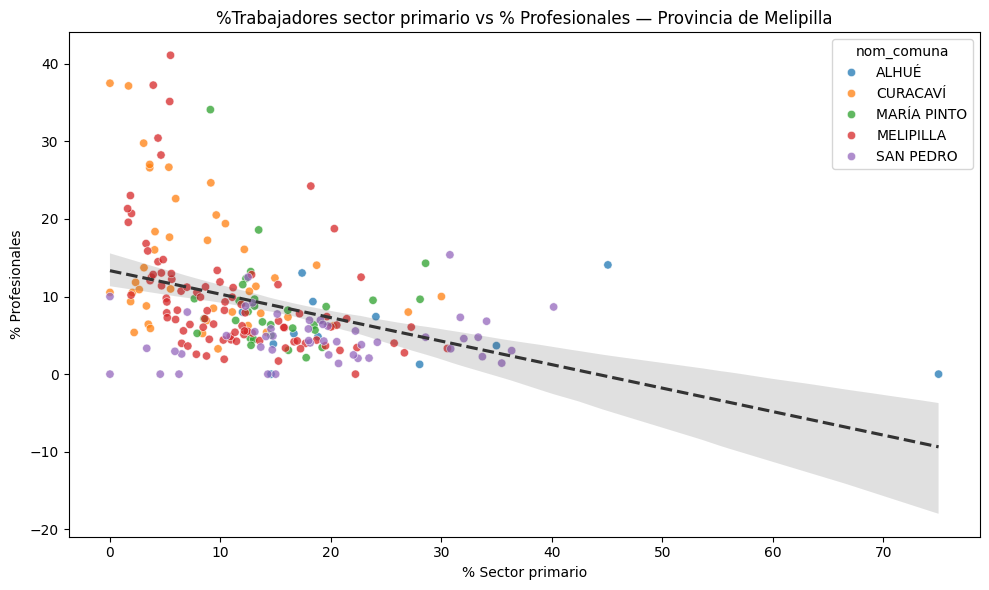

In [14]:
## Generación de gráfico en dispersión de datosn y linea de tendencia.

fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(data=gdf, x='sector_primario', y='porcentaje_profesionales',
                hue='nom_comuna', alpha=0.75, ax=ax)

## Línea de tendencia con las variables del 2017

sns.regplot(data=gdf, x='sector_primario', y='porcentaje_profesionales',
            scatter=False, color='#333', line_kws={'ls': '--'}, ax=ax)

## Textos y etiquetas

ax.set(xlabel='% Sector primario', ylabel='% Profesionales',
       title='%Trabajadores sector primario vs % Profesionales — Provincia de Melipilla')



plt.tight_layout()
plt.show()

### 2.2. Procesamiento y análisis del Censo 2024

Para el año 2024 se utilizó un archivo geoespacial en formato Parquet, el cual contiene variables censales agregadas y las geometrías de las zonas censales de la Región Metropolitana. A diferencia del procesamiento de 2017, esta fuente no requiere relacionar registros individuales de personas, hogares y viviendas, debido a que la información ya se encuentra resumida a nivel zonal.

#### 2.2.1. Carga de la base de datos 

En primer lugar, se definió la ruta del archivo y posteriormente se cargó mediante GeoPandas. El formato Parquet permite almacenar conjuntamente los atributos censales y la geometría de cada zona, facilitando su procesamiento y representación cartográfica en Python.

In [15]:
## Conectamos con la base de datos (.parquet).

RUTA_CENSO_ZONAL = "../IDG/Parquet/Cartografía_censo2024_R13_Zonal.parquet"

In [16]:
## Creamos la variable censo_zonal.

censo_zonal = gpd.read_parquet(RUTA_CENSO_ZONAL)

#### 2.2.2. Indicadores 

Antes de construir los indicadores, se revisaron las columnas disponibles en la base zonal para identificar las variables equivalentes a las utilizadas en 2017. También se comprobaron las comunas incluidas en el archivo.

La revisión mostró que la comuna de San Pedro no se encuentra disponible en la cartografía zonal utilizada para 2024. Por este motivo, el análisis de ese año considera únicamente las comunas de Melipilla, María Pinto, Curacaví y Alhué.

El indicador de actividad primaria se obtuvo mediante la suma de las personas clasificadas en las categorías A y B de actividad económica, correspondientes a agricultura, ganadería, silvicultura y pesca, y explotación de minas y canteras. El resultado se dividió por la población total de cada zona censal:

$$
\text{Actividad primaria 2024 (\%)} =
\frac{\text{Personas en las actividades A y B}}
{\text{Población total de la zona censal}}
\times 100
$$

El indicador educativo se calculó utilizando la cantidad de personas clasificadas en educación terciaria, maestría o doctorado:

$$
\text{Educación superior 2024 (\%)} =
\frac{\text{Personas con educación terciaria, maestría o doctorado}}
{\text{Población total de la zona censal}}
\times 100
$$

Al igual que en 2017, ambos porcentajes se calcularon respecto de la población total de la zona censal. No obstante, la categoría educativa de 2024 es más amplia, porque incorpora educación terciaria, maestría y doctorado, mientras que en 2017 se utilizó la categoría profesional disponible en la variable p15. Esta diferencia deberá considerarse posteriormente al comparar ambos periodos.

In [17]:
## Buscamos las variables de interés.

for col in sorted(censo_zonal.columns):
    print(col)

AREA_C
CATEGORIA
COD_CATEGORIA
COD_DISTRITO
COD_ENTIDAD
COD_LOCALIDAD
COD_PROVINCIA
COD_REGION
COD_ZONA
COMUNA
CUT
DISTRITO
ENTIDAD
ID_DISTRITO
ID_ENTIDAD
ID_LOCALIDAD
ID_ZONA
LOCALIDAD
OBJECTID
PROVINCIA
REGION
SHAPE
SHAPE_Area
SHAPE_Length
n_afrodescendencia
n_analfabet
n_asistencia_basica
n_asistencia_media
n_asistencia_parv
n_asistencia_superior
n_basura_entierra
n_basura_eriazo
n_basura_otro
n_basura_rio
n_basura_servicios
n_caenes_A
n_caenes_B
n_caenes_C
n_caenes_D
n_caenes_E
n_caenes_F
n_caenes_G
n_caenes_H
n_caenes_I
n_caenes_J
n_caenes_K
n_caenes_L
n_caenes_M
n_caenes_N
n_caenes_O
n_caenes_P
n_caenes_Q
n_caenes_R
n_caenes_S
n_caenes_T
n_caenes_U
n_cine_especial_diferencial
n_cine_nunca_curso_primera_infancia
n_cine_primaria
n_cine_secundaria
n_cine_terciaria_maestria_doctorado
n_cise_rec_dependientes
n_cise_rec_independientes
n_cise_rec_trabajador_no_remunerado
n_ciuo_0
n_ciuo_1
n_ciuo_2
n_ciuo_3
n_ciuo_4
n_ciuo_5
n_ciuo_6
n_ciuo_7
n_ciuo_8
n_ciuo_9
n_comb_calefaccion_carbon
n

In [18]:
## No está la comuna de San pedro

print(censo_zonal['COMUNA'].unique())

['BUIN' 'PAINE' 'HUECHURABA' 'COLINA' 'LAMPA' 'TILTIL' 'CONCHALÍ'
 'INDEPENDENCIA' 'RECOLETA' 'LA PINTANA' 'PUENTE ALTO' 'ESTACIÓN CENTRAL'
 'LO PRADO' 'LO ESPEJO' 'PEDRO AGUIRRE CERDA' 'SAN BERNARDO'
 'CALERA DE TANGO' 'EL BOSQUE' 'LA CISTERNA' 'LA FLORIDA' 'PEÑALOLÉN'
 'LA REINA' 'LAS CONDES' 'LO BARNECHEA' 'VITACURA' 'CERRO NAVIA'
 'QUINTA NORMAL' 'CERRILLOS' 'MAIPÚ' 'PUDAHUEL' 'MELIPILLA'
 'ISLA DE MAIPO' 'PADRE HURTADO' 'PEÑAFLOR' 'MACUL' 'ÑUÑOA' 'QUILICURA'
 'RENCA' 'PIRQUE' 'SAN JOSÉ DE MAIPO' 'SAN JOAQUÍN' 'SAN MIGUEL'
 'LA GRANJA' 'SAN RAMÓN' 'SANTIAGO' 'PROVIDENCIA' 'TALAGANTE' 'EL MONTE'
 'ALHUÉ' 'CURACAVÍ' 'MARÍA PINTO']


In [19]:
## Filtramos por las comunas perteneciente a la Provincia de Melipilla
comunas_melipilla = ['MELIPILLA', 'MARÍA PINTO', 'CURACAVÍ', 'ALHUÉ']
gdf_mel_2024 = censo_zonal[censo_zonal['COMUNA'].str.upper().isin(comunas_melipilla)].copy()

## Calcular el sector primario en porcentaje: (sumando A y B, dividido por total de personas de la zona)*100
suma_primario = gdf_mel_2024['n_caenes_A'] + gdf_mel_2024['n_caenes_B']
gdf_mel_2024['sector_primario2'] = (suma_primario / gdf_mel_2024['n_per']).fillna(0) * 100

## Calcular los profesionales en porcentaje (cantidad de personas con nivel profesional aprobado, dividido por el total de personas)*100
gdf_mel_2024['porcentaje_profesionales2'] = (gdf_mel_2024['n_cine_terciaria_maestria_doctorado'] / gdf_mel_2024['n_per']).fillna(0) * 100

In [18]:
## Creamos tabala_resultados al seleccionar las columnas que queremos observar.
tabla_resultados = gdf_mel_2024[['COMUNA', 'ID_ZONA', 'sector_primario2', 'porcentaje_profesionales2']].copy()

## Redondear los porcentajes a 2 decimales para mayor claridad.
tabla_resultados['%_sector_primario2'] = tabla_resultados['sector_primario2'].round(2)
tabla_resultados['%_porcentaje_profesionales2'] = tabla_resultados['porcentaje_profesionales2'].round(2)

## Ordenar alfabéticamente por comuna y numéricamente por ID_ZONA.
tabla_resultados = tabla_resultados.sort_values(by=['COMUNA', 'ID_ZONA'])

## Mostrar la tabla resultante.
display(tabla_resultados)

,COMUNA,ID_ZONA,sector_primario2,porcentaje_profesionales2,%_sector_primario2,%_porcentaje_profesionales2
1848,ALHUÉ,1.350201e+09,13.316936,19.325369,13.32,19.33
1849,ALHUÉ,1.350203e+09,13.882163,13.962873,13.88,13.96
1850,CURACAVÍ,1.350301e+09,3.104787,14.445882,3.10,14.45
1853,CURACAVÍ,1.350301e+09,3.139584,22.528638,3.14,22.53
1851,CURACAVÍ,1.350301e+09,3.017586,12.949640,3.02,12.95
1852,CURACAVÍ,1.350306e+09,2.303961,19.967664,2.30,19.97
1854,CURACAVÍ,1.350306e+09,2.912341,21.337947,2.91,21.34
1855,CURACAVÍ,1.350307e+09,9.741551,16.103380,9.74,16.10
1856,MARÍA PINTO,1.350401e+09,8.624230,14.014374,8.62,14.01
1858,MARÍA PINTO,1.350402e+09,10.198020,3.861386,10.20,3.86


#### 2.2.3.Análisis exploratorio

Una vez calculados los indicadores de 2024, se obtuvieron sus estadísticas descriptivas para revisar la cantidad de zonas analizadas, los valores promedio, la dispersión y los rangos observados. Esta revisión permite comprobar la consistencia de los resultados antes de elaborar los mapas y reconocer posibles diferencias respecto de la distribución registrada en 2017.

In [20]:
## Generamos una tabla resumen de las variables.

gdf_mel_2024[['sector_primario2', 'porcentaje_profesionales2']].describe().round(2)

,sector_primario2,porcentaje_profesionales2
count,42.00,42.00
mean,7.77,15.76
std,4.15,7.56
min,1.34,3.86
25%,3.87,10.98
50%,7.78,13.99
75%,10.19,19.50
max,16.43,35.97


#### 2.2.4. Mapas individuales 2024

A partir de los indicadores calculados, se elaboraron dos mapas coropléticos para representar la distribución espacial del sector primario y de la población con educación terciaria, maestría o doctorado en las zonas censales disponibles para 2024.

Al igual que en 2017, el indicador de actividad primaria fue representado mediante tonalidades verdes, mientras que el indicador educativo se visualizó con una escala de colores morados. Las tonalidades más intensas indican una mayor presencia relativa de cada variable respecto de la población total de la zona censal.

Debe considerarse que la cartografía zonal utilizada para 2024 no incluye la comuna de San Pedro, por lo que los mapas abarcan únicamente Melipilla, María Pinto, Curacaví y Alhué.

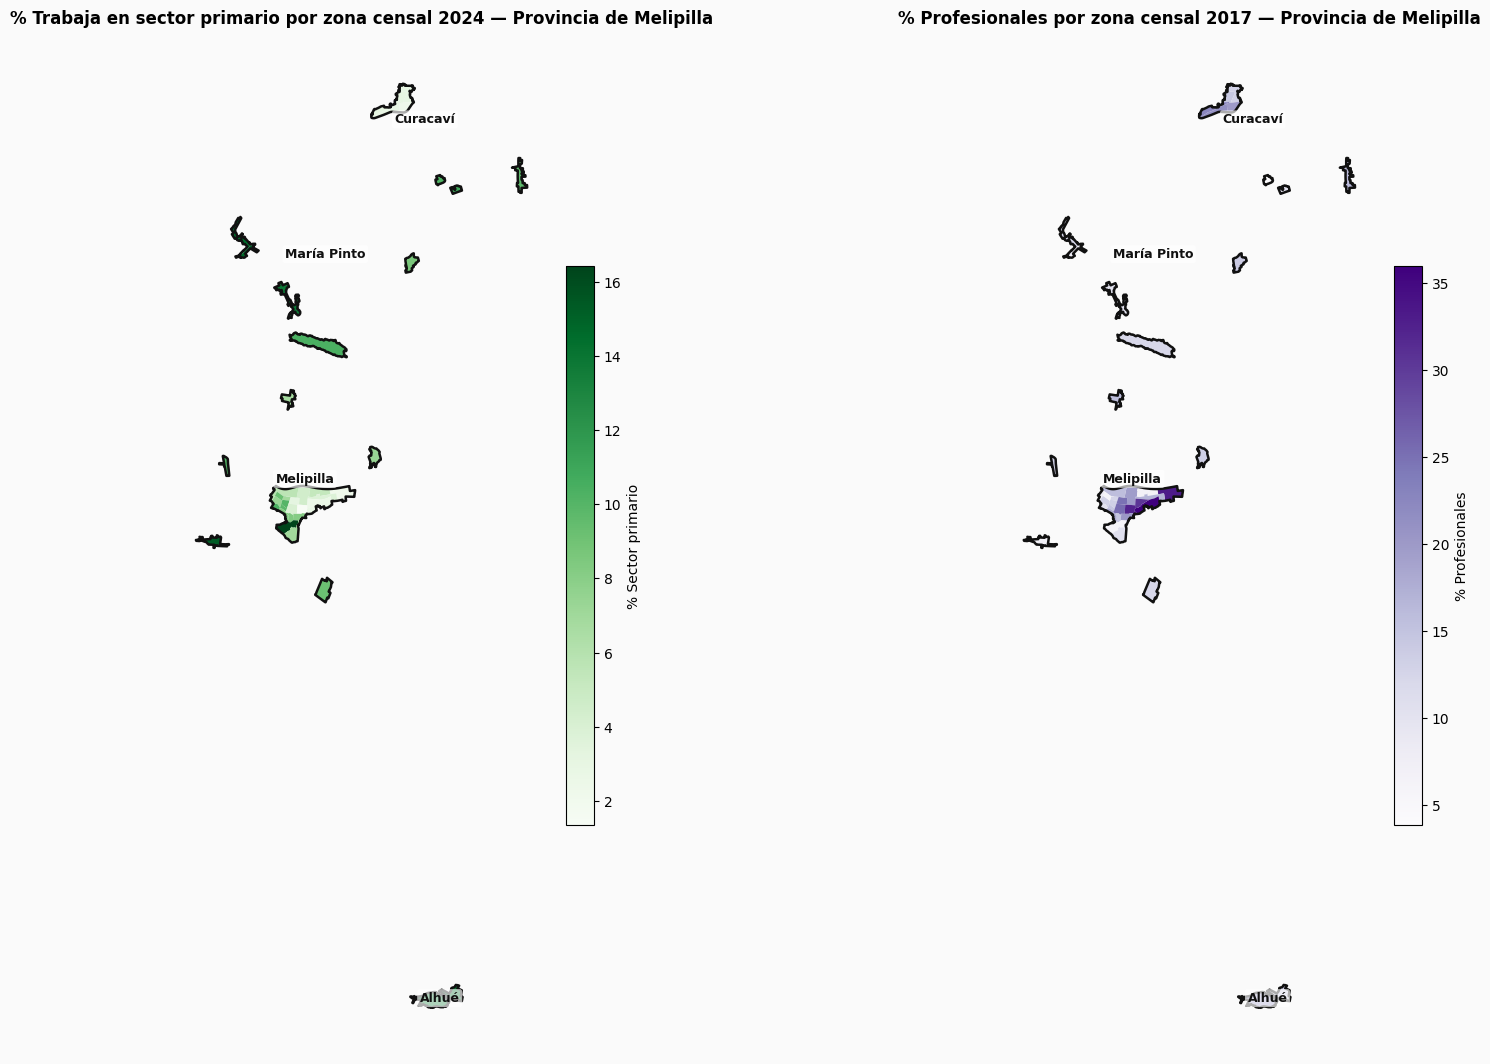

In [21]:
## Generamos mapa para cada variable y poder observar como se disponen los porcentajes en el espacio.

def plot_univariado_2024(ax, gdf_z, gdf_c, gdf_ct, col, cmap, titulo, cbar_label):
    gdf_z.plot(
        column=col, ax=ax, cmap=cmap, linewidth=0,
        legend=True,
        legend_kwds={'label': cbar_label, 'shrink': 0.55, 'pad': 0.02}
    )
    gdf_c.plot(ax=ax, facecolor='none', edgecolor='#111', linewidth=1.8)
    
    for _, row in gdf_ct.iterrows():
        ax.annotate(
            row['COMUNA'].title(), 
            xy=(row.geometry.x, row.geometry.y),
            ha='center', va='center',
            fontsize=9, fontweight='bold', color='#111',
            bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.65, ec='none')
        )
    ax.set_title(titulo, fontsize=12, fontweight='bold', pad=10)
    ax.axis('off')

gdf_comunas_mel = gdf_mel_2024.dissolve(by='COMUNA').reset_index()

gdf_centroides_mel = gdf_comunas_mel.copy()
gdf_centroides_mel['geometry'] = gdf_comunas_mel.to_crs(epsg=3857).centroid.to_crs(gdf_comunas_mel.crs)

fig, axes = plt.subplots(1, 2, figsize=(20, 11))
fig.patch.set_facecolor('#fafafa')

plot_univariado_2024(
    axes[0], gdf_mel_2024, gdf_comunas_mel, gdf_centroides_mel,
    'sector_primario2', 'Greens',
    '% Trabaja en sector primario por zona censal 2024 — Provincia de Melipilla',
    '% Sector primario'
)

plot_univariado_2024(
    axes[1], gdf_mel_2024, gdf_comunas_mel, gdf_centroides_mel,
    'porcentaje_profesionales2', 'Purples',
    '% Profesionales por zona censal 2017 — Provincia de Melipilla',
    '% Profesionales'
)

plt.tight_layout(pad=2)
plt.show()

Los mapas de 2024 muestran una cobertura territorial considerablemente menor que los de 2017. Esto se debe a que el archivo Parquet utilizado no contiene la misma cantidad de zonas censales ni la misma continuidad espacial que la base de datos empleada para 2017. Como resultado, solo se representan polígonos aislados de Curacaví, María Pinto, Melipilla y Alhué, sin cubrir de manera continua toda la provincia.

Dentro de las zonas disponibles, el sector primario presenta sus valores más altos en algunos polígonos de Melipilla y María Pinto, mientras que el indicador de profesionales se concentra principalmente en zonas de Melipilla y, en menor medida, Curacaví. Sin embargo, estos patrones deben interpretarse con cautela, porque la información disponible no permite comparar directamente toda la distribución territorial de 2024 con la observada en 2017.

Por lo tanto, las diferencias entre ambos años pueden estar asociadas tanto a cambios reales en los indicadores como a diferencias en la estructura, cobertura y delimitación de las fuentes censales. Esta limitación reduce la comparabilidad cartográfica y debe considerarse en el análisis temporal posterior.

#### 2.2.5. Clasificación de cuadrante de colores

Los indicadores de 2024 fueron clasificados en tres niveles —bajo, medio y alto— mediante el método Fisher-Jenks. Posteriormente, ambas variables se combinaron en una matriz bivariada de nueve categorías.

El primer valor representa el nivel de actividad primaria y el segundo el nivel de población profesional. De este modo, los tonos verdes indican una mayor presencia del sector primario, mientras que los tonos morados representan una mayor proporción de profesionales. Las combinaciones intermedias muestran distintos niveles relativos de ambas variables.

Debido a la cobertura incompleta del archivo Parquet, esta clasificación solo representa las zonas censales disponibles y no la totalidad de la provincia.

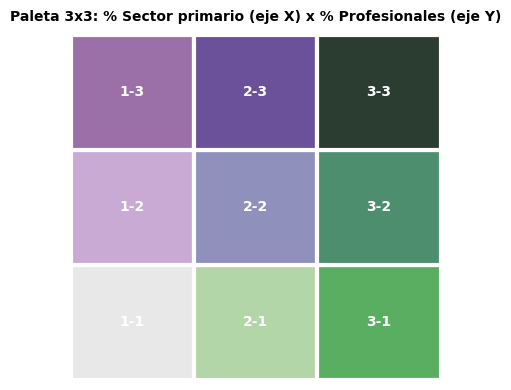

In [22]:
## Definimos cantidad de cuadrantes y sus respectivos colores en preparación pora el mapa bivariado.

BIVARIATE_COLORS = {
    '1-1': '#e8e8e8',  # bajo-bajo   → neutro claro
    '2-1': '#b2d6a7',  # medio-bajo  → verde claro
    '3-1': '#5aae61',  # alto-bajo   → verde pleno
    '1-2': '#c8aad4',  # bajo-medio  → morado claro
    '2-2': '#9090bc',  # medio-medio → pizarra azul
    '3-2': '#4d8e6e',  # alto-medio  → verde-azul oscuro
    '1-3': '#9b6fa8',  # bajo-alto   → morado pleno
    '2-3': '#6b509a',  # medio-alto  → morado profundo
    '3-3': '#2b3d30',  # alto-alto   → verde muy oscuro
}

fig_pal, ax_pal = plt.subplots(figsize=(4, 4))
for key, color in BIVARIATE_COLORS.items():
    i, j = map(int, key.split('-'))
    ax_pal.add_patch(plt.Rectangle(
        ((i - 1) / 3, (j - 1) / 3), 1/3, 1/3,
        transform=ax_pal.transAxes,
        facecolor=color, edgecolor='white', linewidth=3, clip_on=False
    ))
    ax_pal.text(
        (i - 0.5) / 3, (j - 0.5) / 3, key,
        ha='center', va='center', fontsize=10, color='white',
        fontweight='bold', transform=ax_pal.transAxes
    )
ax_pal.set_xlim(0, 1)
ax_pal.set_ylim(0, 1)
ax_pal.axis('off')
ax_pal.set_title('Paleta 3x3: % Sector primario (eje X) x % Profesionales (eje Y)',
                 fontsize=10, fontweight='bold', pad=10)
plt.tight_layout()
plt.show()

In [23]:
cls_x = mapclassify.FisherJenks(gdf_mel_2024['sector_primario2'].values, k=3)
cls_y = mapclassify.FisherJenks(gdf_mel_2024['porcentaje_profesionales2'].values, k=3)

gdf_bi = gdf_mel_2024.copy()
gdf_bi['class_x']  = cls_x.yb + 1 
gdf_bi['class_y']  = cls_y.yb + 1
gdf_bi['bi_class'] = gdf_bi['class_x'].astype(str) + '-' + gdf_bi['class_y'].astype(str)
gdf_bi['color']    = gdf_bi['bi_class'].map(BIVARIATE_COLORS)

print('Cortes Jenks — % Sector Primario (2024):')
print([round(b, 2) for b in cls_x.bins])

print('\nCortes Jenks — % Profesionales (2024):')
print([round(b, 2) for b in cls_y.bins])

print(f'\nDistribución de clases bivariadas:')
print(gdf_bi['bi_class'].value_counts().sort_index())

sin_color = gdf_bi[gdf_bi['color'].isna()]
if len(sin_color) == 0:
    print('\nTodas las zonas tienen color asignado')
else:
    print(f'\nAtención: {len(sin_color)} zonas sin color: {sin_color["bi_class"].unique()}')

Cortes Jenks — % Sector Primario (2024):
[5.99, 11.06, 16.43]

Cortes Jenks — % Profesionales (2024):
[13.45, 22.53, 35.97]

Distribución de clases bivariadas:
bi_class
1-1     3
1-2     7
1-3     6
2-1    12
2-2     7
3-1     5
3-2     2
Name: count, dtype: int64

Todas las zonas tienen color asignado


C:\Users\renat\anaconda3\envs\geo\Lib\site-packages\IPython\core\interactiveshell.py:3526: UserWarning: Numba not installed. Using slow pure python version.
  exec(code_obj, self.user_global_ns, self.user_ns)


#### 2.2.6. Mapa bivariado 2024

El mapa bivariado representa conjuntamente los niveles de actividad primaria y población profesional en las zonas censales disponibles para 2024. Su lectura utiliza la misma combinación de colores aplicada en 2017, aunque los resultados deben interpretarse considerando la menor cobertura territorial de la fuente.

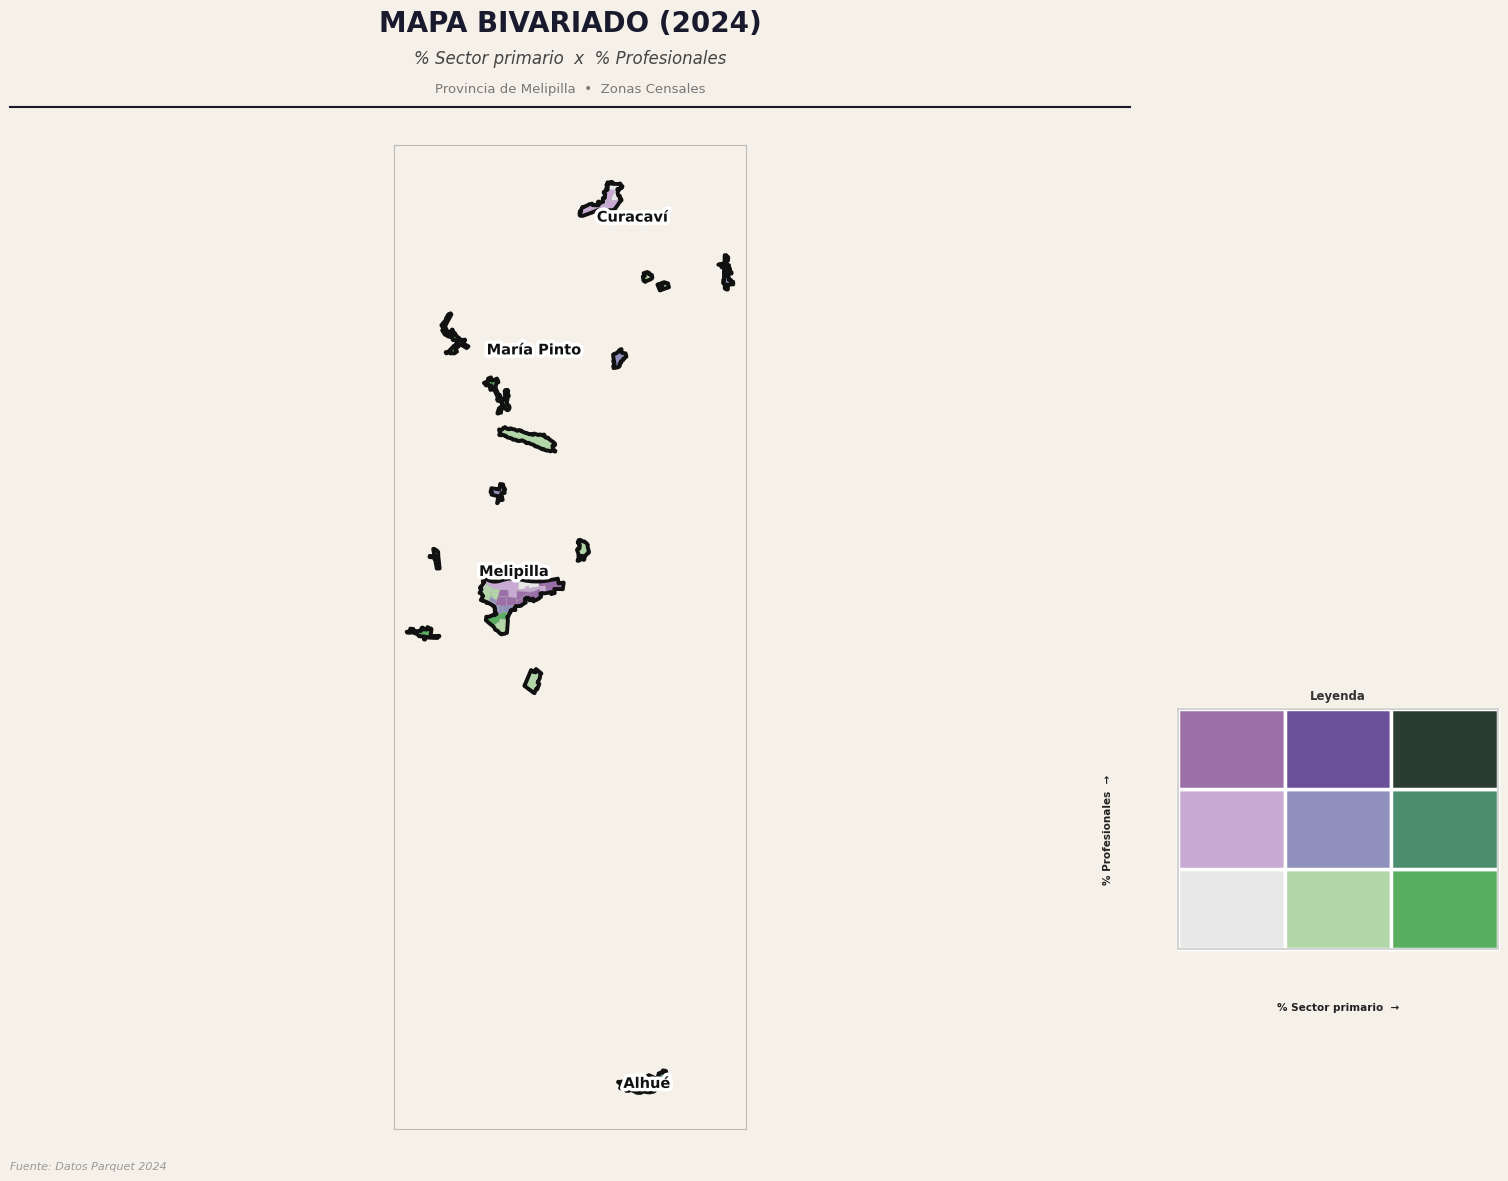

In [24]:
# 1. Preparar las capas desde tu tabla bivariada del 2024 (gdf_bi)
gdf_bi_mel = gdf_bi.copy()

## Crear bordes comunales disolviendo las zonas
gdf_comunas_mel = gdf_bi_mel.dissolve(by='COMUNA').reset_index()

## Calcular centroides
gdf_centroides_mel = gdf_comunas_mel.copy()
gdf_centroides_mel['geometry'] = gdf_comunas_mel.to_crs(epsg=3857).centroid.to_crs(gdf_comunas_mel.crs)

## Función para la leyenda bivariada
def crear_leyenda_bivariada(ax, colores, xlab, ylab, dim=3):
    for i in range(1, dim + 1):
        for j in range(1, dim + 1):
            ax.add_patch(plt.Rectangle(
                ((i - 1) / dim, (j - 1) / dim),
                1 / dim, 1 / dim,
                transform=ax.transAxes,
                facecolor=colores[f'{i}-{j}'],
                edgecolor='white',
                linewidth=2.5,
                clip_on=False
            ))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.text(0.5, -0.22, xlab,
            ha='center', va='top', fontsize=7.5, transform=ax.transAxes,
            color='#222', fontweight='bold', clip_on=False)
    ax.text(-0.22, 0.5, ylab,
            ha='center', va='center', fontsize=7.5, transform=ax.transAxes,
            rotation=90, color='#222', fontweight='bold', clip_on=False)

## Figura y layout 
fig = plt.figure(figsize=(16, 12))
fig.patch.set_facecolor('#f5f0e8')      # fondo general

ax_map = fig.add_axes([0.02, 0.05, 0.70, 0.82])   # mapa
ax_leg = fig.add_axes([0.75, 0.20, 0.20, 0.20])   # leyenda

## Mapa
ax_map.set_facecolor('#f5f0e8') 

## Zonas censales filtradas 2024
gdf_bi_mel.plot(
    color=gdf_bi_mel['color'].tolist(), ax=ax_map,
    linewidth=0.2, edgecolor='#aaaaaa', zorder=2
)

## Límites comunales de Melipilla
gdf_comunas_mel.plot(
    ax=ax_map, facecolor='none', edgecolor='#111111',
    linewidth=2.8, zorder=4
)

## Etiquetas
for _, row in gdf_centroides_mel.iterrows():
    txt = ax_map.annotate(
        row['COMUNA'].title(), # .title() para que se vea como 'Melipilla'
        xy=(row.geometry.x, row.geometry.y),
        ha='center', va='center',
        fontsize=10.5, fontweight='bold', color='#111111', zorder=6
    )
    txt.set_path_effects([pe.withStroke(linewidth=5, foreground='white')])

## Encuadre en Melipilla
minx, miny, maxx, maxy = gdf_comunas_mel.total_bounds
margin_x = (maxx - minx) * 0.04
margin_y = (maxy - miny) * 0.04

ax_map.set_xlim(minx - margin_x, maxx + margin_x)
ax_map.set_ylim(miny - margin_y, maxy + margin_y)

## Marco del mapa
for spine in ax_map.spines.values():
    spine.set_visible(True)
    spine.set_color('#bbbbbb')
    spine.set_linewidth(0.8)
ax_map.set_xticks([])
ax_map.set_yticks([])

## Bloque de títulos 
fig.text(0.37, 0.965, 'MAPA BIVARIADO (2024)', ha='center',
         fontsize=20, fontweight='bold', color='#1a1a2e')
fig.text(0.37, 0.938, '% Sector primario  x  % Profesionales', ha='center',
         fontsize=12, color='#444', style='italic')
fig.text(0.37, 0.914, 'Provincia de Melipilla  •  Zonas Censales',
         ha='center', fontsize=9.5, color='#777')

## Línea separadora
fig.add_artist(Line2D([0.02, 0.72], [0.902, 0.902],
                      transform=fig.transFigure,
                      color='#1a1a2e', linewidth=1.5))

## Fuente
fig.text(0.02, 0.017, 'Fuente: Datos Parquet 2024',
         ha='left', fontsize=8, color='#999', style='italic')

## Leyenda bivariada 
ax_leg.set_facecolor('white')
for spine in ax_leg.spines.values():
    spine.set_visible(True)
    spine.set_color('#cccccc')
    spine.set_linewidth(1.2)

crear_leyenda_bivariada(
    ax_leg, BIVARIATE_COLORS,
    xlab='% Sector primario  →',
    ylab='% Profesionales  →'
)
ax_leg.set_title('Leyenda', fontsize=8.5, fontweight='bold', pad=7, color='#333')

plt.show()

El mapa bivariado de 2024 muestra combinaciones diversas entre actividad primaria y población profesional en las zonas disponibles. En Curacaví predominan tonos morados, asociados con una mayor presencia relativa de profesionales y niveles bajos o intermedios de actividad primaria. En Melipilla se observan combinaciones más heterogéneas, con zonas moradas, verdes y mixtas.

María Pinto presenta principalmente categorías vinculadas con una mayor participación del sector primario, mientras que Alhué aparece representado por una cantidad muy reducida de zonas, lo que limita su interpretación. En general, el mapa sugiere que los sectores con mayor actividad primaria tienden a presentar una menor proporción de profesionales, aunque esta relación no es uniforme.

El análisis es incompleto y no es comparable con el Censo 2017, debido a que la cobertura del archivo Parquet es incompleta y no representa de manera continua toda la provincia. Por ello, el mapa permite describir únicamente las zonas disponibles y no realizar una comparación territorial directa con 2017.

#### 2.2.7.Gráfico de dispersión 2024

Para complementar el mapa bivariado, se elaboró un gráfico de dispersión entre el porcentaje de población vinculada con el sector primario y el porcentaje de población profesional. Cada punto representa una de las zonas censales disponibles en el archivo de 2024.

La línea de tendencia permite observar la dirección general de la relación entre ambas variables. Sin embargo, el resultado debe interpretarse únicamente como una asociación exploratoria, considerando la cobertura incompleta de la base Parquet.

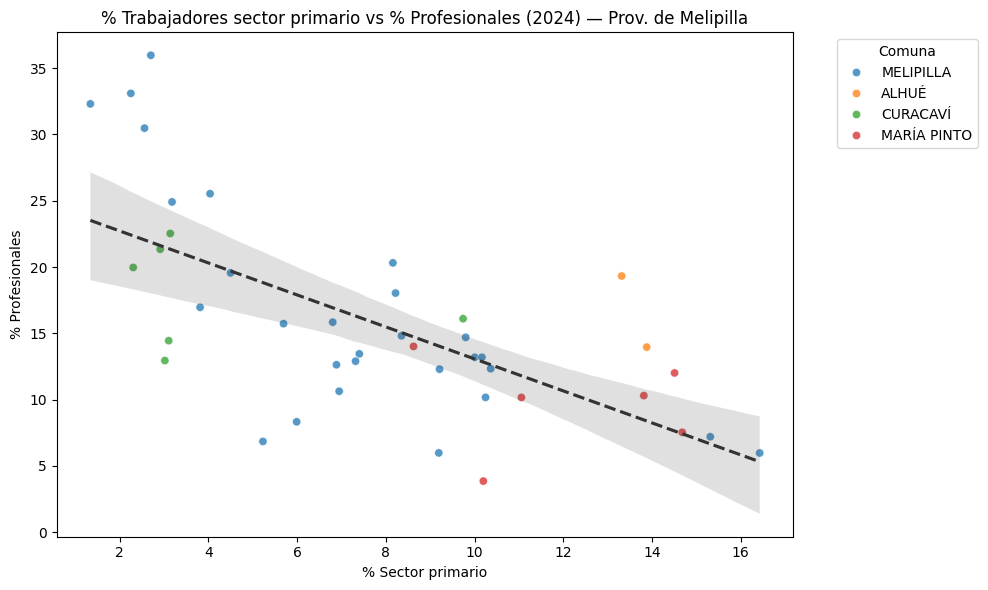

In [25]:
## Generación de gráfico en dispersión de datos y linea de tendencia.

ig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=gdf_mel_2024, x='sector_primario2', y='porcentaje_profesionales2',
                hue='COMUNA', alpha=0.75, ax=ax)

## Línea de tendencia con las variables del 2024
sns.regplot(data=gdf_mel_2024, x='sector_primario2', y='porcentaje_profesionales2',
            scatter=False, color='#333', line_kws={'ls': '--'}, ax=ax)

## Textos y etiquetas
ax.set(xlabel='% Sector primario', ylabel='% Profesionales',
       title='% Trabajadores sector primario vs % Profesionales (2024) — Prov. de Melipilla')

plt.legend(title='Comuna', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

---

## 3. Conclusión 

El trabajo permitió analizar la distribución territorial de la actividad económica primaria y de la población con educación superior en la provincia de Melipilla, utilizando información censal de 2017 y 2024 a nivel de zona censal. Mediante Python se construyeron indicadores porcentuales, mapas individuales y mapas bivariados que permitieron reconocer diferencias internas entre las comunas y distintas combinaciones entre ambas variables.

Los resultados de 2017 muestran una mayor presencia relativa de actividades primarias en sectores rurales y periféricos, particularmente en San Pedro, Alhué y algunas zonas del sur de Melipilla. En cambio, las mayores proporciones de población profesional se concentran principalmente en Curacaví y en sectores centrales de Melipilla. El mapa bivariado permitió observar una tendencia en la que las zonas con mayor presencia del sector primario suelen presentar una menor proporción de profesionales, aunque también se identificaron configuraciones intermedias, especialmente en María Pinto y Melipilla.

Para 2024 se construyeron los mismos tipos de representaciones; sin embargo, los resultados solo describen las zonas disponibles en el archivo Parquet. Esta fuente presentó una cobertura territorial incompleta, con polígonos aislados y una cantidad de zonas censales considerablemente menor que la base utilizada para 2017. Además, no incluyó la comuna de San Pedro y utilizó una categoría educativa más amplia, que agrupa educación terciaria, maestría y doctorado, mientras que en 2017 se utilizó la categoría profesional disponible en la variable censal.

Estas diferencias impidieron realizar una comparación temporal directa y metodológicamente válida. Las zonas censales de ambos años no poseen la misma cobertura, delimitación ni cantidad de unidades, por lo que no fue posible establecer correspondencias espaciales consistentes entre ellas. En consecuencia, cualquier diferencia observada podría deberse tanto a cambios reales en la población como a las características distintas de las fuentes, y no sería correcto interpretarla directamente como aumento, disminución o permanencia entre 2017 y 2024.

Por esta razón, no se elaboró un mapa de cambio temporal. Esta decisión constituye una limitación respecto de lo solicitado en el trabajo, pero evita presentar resultados potencialmente engañosos. Una comparación futura requeriría disponer de la cartografía completa de 2024 y aplicar una estrategia de homologación espacial, como la agregación de ambos años a unidades territoriales comunes, la construcción de una tabla de correspondencia entre zonas censales o una interpolación basada en la superposición de polígonos.

A pesar de esta limitación, el análisis entrega información útil para la planificación territorial. Los resultados pueden apoyar la identificación de sectores donde una alta presencia de actividades primarias coincide con una menor concentración de población profesional, orientando programas de formación técnica, capacitación laboral, conectividad y fortalecimiento productivo. También podrían utilizarse para localizar servicios educativos, centros de capacitación o iniciativas de apoyo a actividades agrícolas y extractivas, considerando las características específicas de cada zona.

---

## 4. Bibliografía

* Berdegué, J. A., Jara, E., Modrego, F., Sanclemente, X., & Schejtman, A. (2010). Comunas rurales de Chile. Centro Latinoamericano para el Desarrollo Rural. https://rimisp.org/comunas-rurales-de-chile/

* Canales, A., Canales, M., & Hernández, M. (2018). Trabajo y territorio en el nuevo agro chileno: Un estudio de commuters en tres comarcas del Valle Central. EURE, 44(131), 5–28. https://doi.org/10.4067/S0250-71612018000100005

* Cazzuffi, C., López, D., & Del Valle, V. (2020). Crecimiento e inclusión en los territorios rurales-urbanos de Chile. Sobre México. Temas de Economía, 1(1). https://rimisp.org/crecimiento-e-inclusion-en-los-territorios-rurales-urbanos-de-chile/

* Instituto Nacional de Estadísticas. (2018). Censo de población y vivienda 2017: Base de microdatos y cartografía censal. https://www.ine.gob.cl/sala-de-prensa/prensa/general/noticia/2019/09/16/ine-pone-a-disposici%C3%B3n-la-base-de-microdatos-del-censo-2017

* Instituto Nacional de Estadísticas. (2025). Base de datos del Censo de Población y Vivienda 2024. https://censo2024.ine.gob.cl/ine-publica-base-de-datos-del-censo-de-poblacion-y-vivienda-2024/

* Kerrigan Richard, G. (2017). Formación técnica y profesional y capacitación para el sector rural en Chile. Comisión Económica para América Latina y el Caribe. https://www.cepal.org/es/documentos/formacion-tecnica-profesional-capacitacion-sector-rural-chile

* Oficina de Estudios y Políticas Agrarias. (2019). Región Metropolitana: Información regional 2019. Ministerio de Agricultura, Gobierno de Chile. https://www.odepa.gob.cl/wp-content/uploads/2019/03/Metropolitana.pdf

* Pérez Silva, R. (2023). Estado actual y transformaciones del empleo rural en América Latina: Un análisis del caso de Chile. Chilean Journal of Agricultural & Animal Sciences, 39(1), 121–132. https://doi.org/10.29393/CHJAA39-10EARP10010